In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/tata-motors-stock-details1995-2025/TATAMOTORS_NSE_1995-2025.csv


## Title: Tata Motors Stock Details (1995–2025)

## Description:
This dataset captures the historical performance of Tata Motors’ stock prices from 1995 to 2025, offering insights into the company’s long-term financial journey. It includes details such as opening price, closing price, highest and lowest values, trading volumes, and overall market trends across three decades. By analyzing this data, one can explore growth patterns, market cycles, global financial impacts, and sector-specific developments that influenced Tata Motors’ valuation. This dataset is valuable for investors, financial analysts, and researchers interested in understanding Tata Motors’ stock behavior, predicting future performance, and studying the broader automobile industry’s evolution in India and global markets.

## Import dataset

In [2]:
df = pd.read_csv("/kaggle/input/tata-motors-stock-details1995-2025/TATAMOTORS_NSE_1995-2025.csv")

In [3]:
df.head()

,Unnamed: 0,Date,Symbol,Open,High,Low,Close,PrevClose,Volume,Turnover,VWAP,Trades,Daily_Return_%,MA_20,MA_50
0,223,1995-01-02,TATAMOTORS,517.5,524.7,517.5,524.2,522.0,1100,573530.0,521.39,NaN,0.421456,NaN,NaN
1,224,1995-01-03,TATAMOTORS,518.0,520.0,515.0,515.0,524.2,1500,775450.0,516.97,NaN,-1.755055,NaN,NaN
2,225,1995-01-04,TATAMOTORS,515.0,515.0,515.0,515.0,515.0,300,154500.0,515.00,NaN,0.000000,NaN,NaN
3,226,1995-01-05,TATAMOTORS,480.0,480.0,480.0,480.0,515.0,50,24000.0,480.00,NaN,-6.796117,NaN,NaN
4,227,1995-01-06,TATAMOTORS,495.0,501.0,495.0,498.7,480.0,200,99550.0,497.75,NaN,3.895833,NaN,NaN


In [4]:
df.tail()

,Unnamed: 0,Date,Symbol,Open,High,Low,Close,PrevClose,Volume,Turnover,VWAP,Trades,Daily_Return_%,MA_20,MA_50
7799,7660,2025-08-12,TATAMOTORS,651.10,660.95,650.80,654.10,653.75,11212223,7.348231e+09,655.38,223425.0,0.053537,669.3700,683.496
7800,7661,2025-08-13,TATAMOTORS,657.20,667.00,656.65,663.75,654.10,7557556,5.016113e+09,663.72,133862.0,1.475310,668.6075,682.568
7801,7662,2025-08-14,TATAMOTORS,666.00,666.55,657.70,664.60,663.75,6250494,4.140530e+09,662.43,115002.0,0.128060,667.7525,681.640
7802,7663,2025-08-18,TATAMOTORS,677.00,685.00,672.90,676.00,664.60,14226172,9.655303e+09,678.70,165366.0,1.715317,667.5400,680.804
7803,7664,2025-08-19,TATAMOTORS,676.75,703.35,673.10,700.25,676.00,19440384,1.351303e+10,695.10,282726.0,3.587278,668.1800,680.164


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7804 entries, 0 to 7803
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      7804 non-null   int64  
 1   Date            7804 non-null   object 
 2   Symbol          7804 non-null   object 
 3   Open            7804 non-null   float64
 4   High            7804 non-null   float64
 5   Low             7804 non-null   float64
 6   Close           7804 non-null   float64
 7   PrevClose       7804 non-null   float64
 8   Volume          7804 non-null   int64  
 9   Turnover        7804 non-null   float64
 10  VWAP            7804 non-null   float64
 11  Trades          3617 non-null   float64
 12  Daily_Return_%  7804 non-null   float64
 13  MA_20           7785 non-null   float64
 14  MA_50           7755 non-null   float64
dtypes: float64(11), int64(2), object(2)
memory usage: 914.7+ KB


In [6]:
df.describe()

,Unnamed: 0,Open,High,Low,Close,PrevClose,Volume,Turnover,VWAP,Trades,Daily_Return_%,MA_20,MA_50
count,7804.000000,7804.000000,7804.000000,7804.000000,7804.000000,7804.000000,7.804000e+03,7.804000e+03,7804.000000,3.617000e+03,7804.000000,7785.000000,7755.000000
mean,3901.500000,426.908105,433.624885,419.198526,426.156516,426.042984,1.008443e+07,3.360758e+09,426.517865,1.641804e+05,inf,425.784914,425.176591
std,2252.965083,260.410952,263.730360,256.249596,259.926045,259.923227,1.998049e+07,5.490162e+09,259.954308,1.309842e+05,NaN,258.907945,257.163936
min,0.000000,58.000000,60.700000,57.550000,58.800000,0.000000,5.000000e+01,2.400000e+04,59.240000,3.434000e+03,-80.866780,64.885000,69.538000
25%,1950.750000,215.950000,220.187500,209.437500,215.375000,215.375000,1.365342e+06,4.126361e+08,215.487500,8.477600e+04,-1.418222,215.867500,219.790000
50%,3901.500000,399.000000,404.525000,392.175000,397.800000,397.800000,4.114132e+06,1.913436e+09,398.320000,1.263780e+05,0.013436,398.915000,401.483000
75%,5852.250000,535.000000,544.000000,526.262500,535.312500,535.312500,9.874223e+06,3.942626e+09,535.530000,1.993340e+05,1.490380,533.560000,525.136500
max,7803.000000,1361.000000,1382.000000,1347.000000,1365.150000,1365.150000,3.905778e+08,9.853175e+10,1362.150000,1.517162e+06,inf,1316.080000,1270.157000


In [7]:
df.dtypes

Unnamed: 0          int64
Date               object
Symbol             object
Open              float64
High              float64
Low               float64
Close             float64
PrevClose         float64
Volume              int64
Turnover          float64
VWAP              float64
Trades            float64
Daily_Return_%    float64
MA_20             float64
MA_50             float64
dtype: object

In [8]:
df.shape

(7804, 15)

In [9]:
df.isnull().sum()

Unnamed: 0           0
Date                 0
Symbol               0
Open                 0
High                 0
Low                  0
Close                0
PrevClose            0
Volume               0
Turnover             0
VWAP                 0
Trades            4187
Daily_Return_%       0
MA_20               19
MA_50               49
dtype: int64

In [10]:
df.duplicated().sum()

0

In [11]:
df.columns

Index(['Unnamed: 0', 'Date', 'Symbol', 'Open', 'High', 'Low', 'Close',
       'PrevClose', 'Volume', 'Turnover', 'VWAP', 'Trades', 'Daily_Return_%',
       'MA_20', 'MA_50'],
      dtype='object')

## Data visualizations

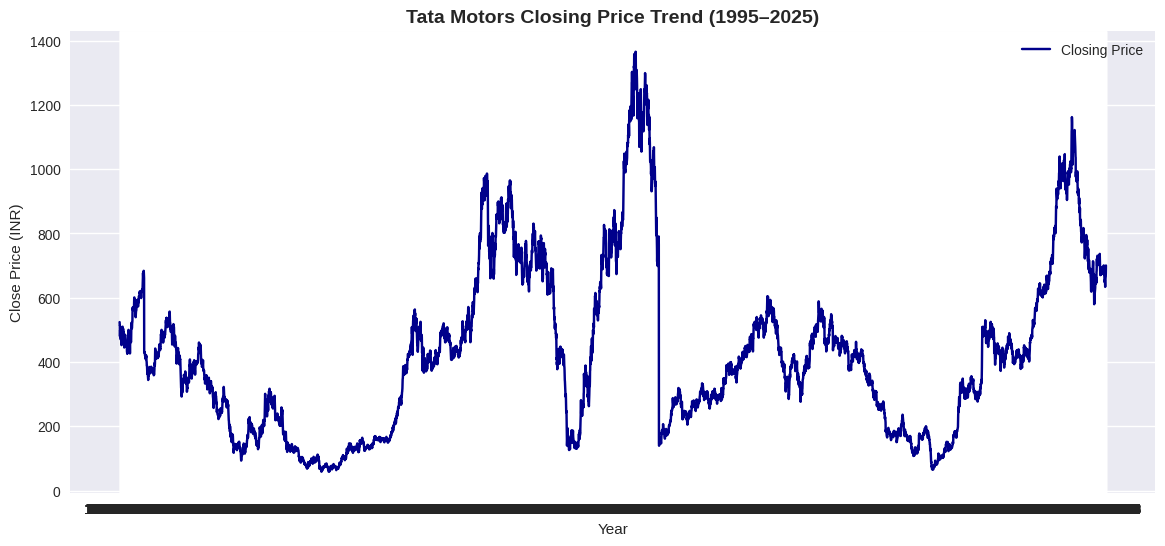

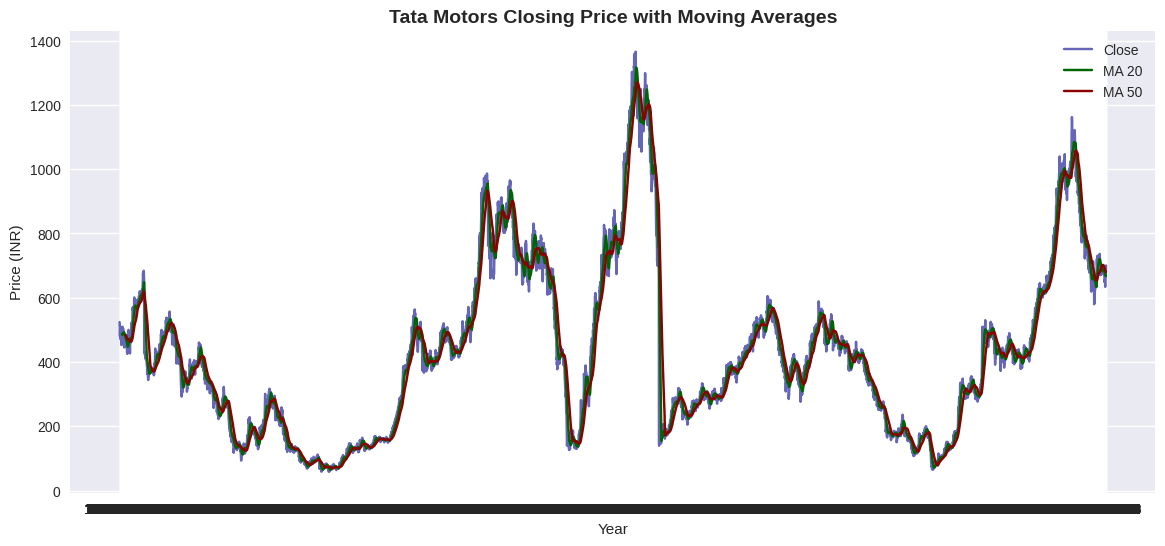

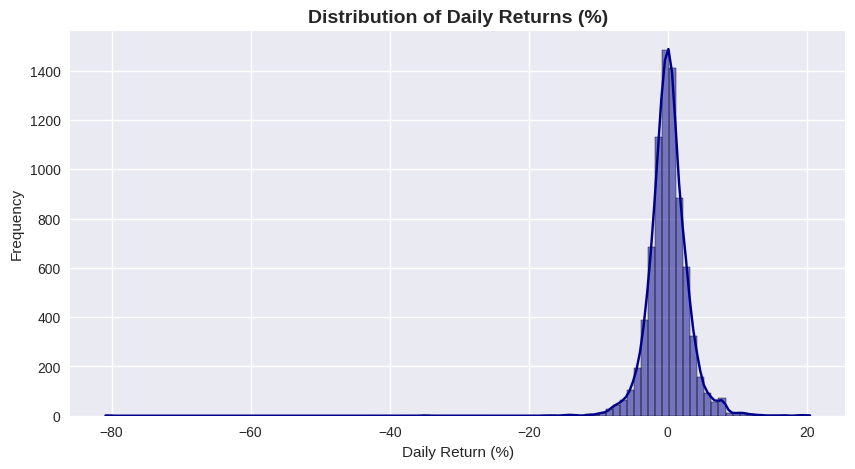

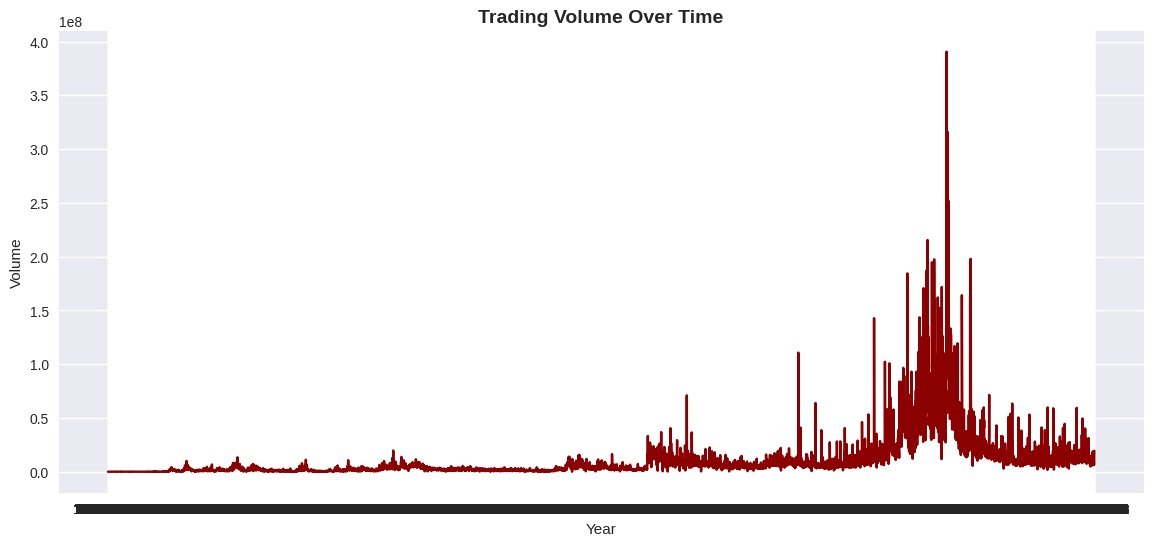

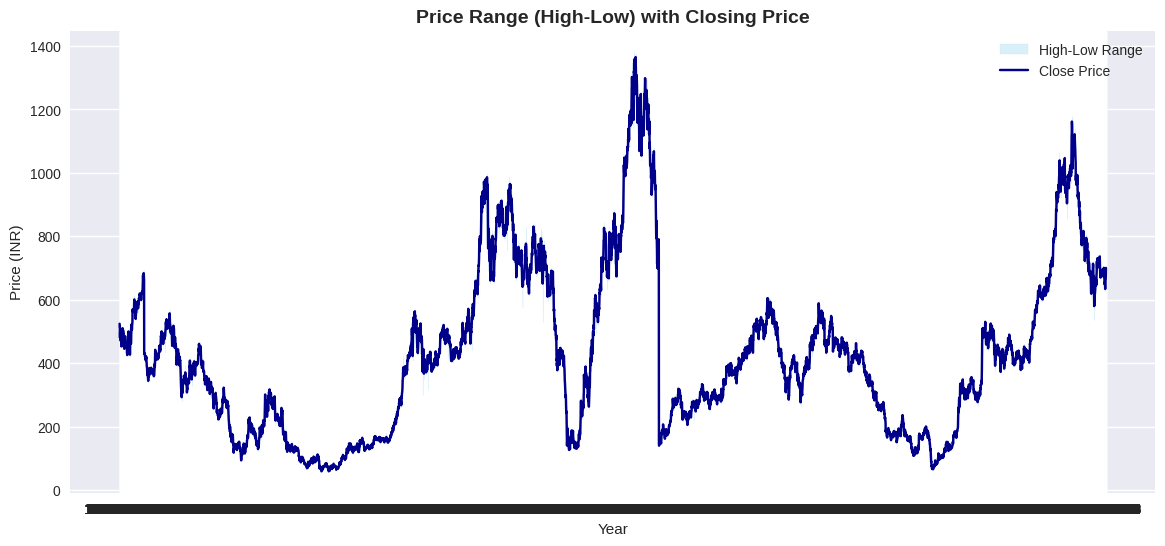

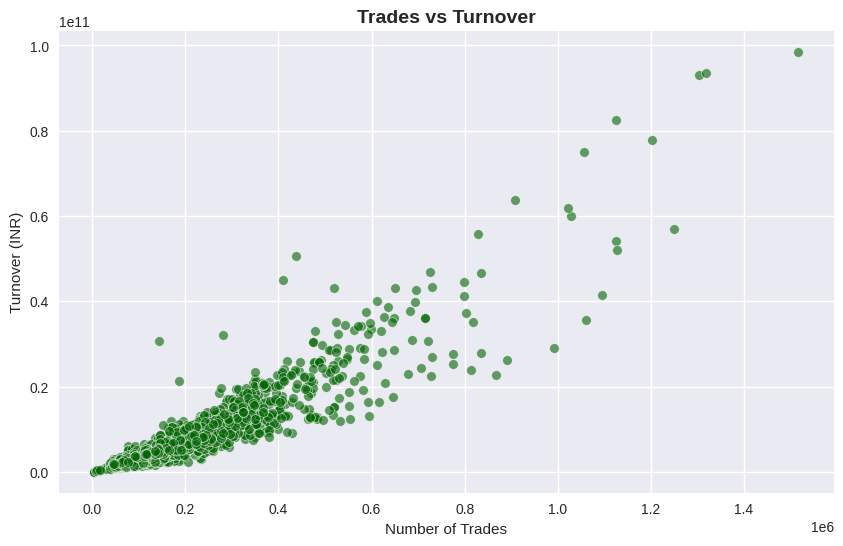

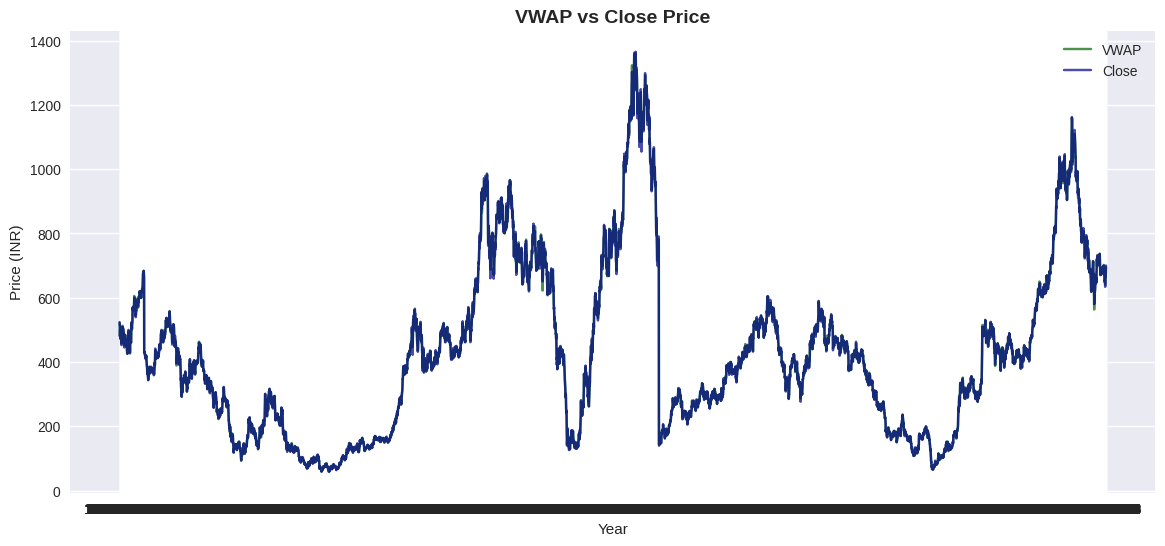

In [12]:
# Set style
plt.style.use("seaborn-v0_8")
sns.set_palette("crest")

# 1. Closing Price Trend (1995–2025)
plt.figure(figsize=(14,6))
plt.plot(df['Date'], df['Close'], label="Closing Price", color="darkblue")
plt.title("Tata Motors Closing Price Trend (1995–2025)", fontsize=14, weight="bold")
plt.xlabel("Year")
plt.ylabel("Close Price (INR)")
plt.legend()
plt.show()

# 2. Closing Price with Moving Averages (20 & 50 days)
plt.figure(figsize=(14,6))
plt.plot(df['Date'], df['Close'], label="Close", color="darkblue", alpha=0.6)
plt.plot(df['Date'], df['MA_20'], label="MA 20", color="darkgreen")
plt.plot(df['Date'], df['MA_50'], label="MA 50", color="darkred")
plt.title("Tata Motors Closing Price with Moving Averages", fontsize=14, weight="bold")
plt.xlabel("Year")
plt.ylabel("Price (INR)")
plt.legend()
plt.show()

# 3. Daily Returns Distribution
plt.figure(figsize=(10,5))
sns.histplot(df['Daily_Return_%'], bins=100, kde=True, color="darkblue")
plt.title("Distribution of Daily Returns (%)", fontsize=14, weight="bold")
plt.xlabel("Daily Return (%)")
plt.ylabel("Frequency")
plt.show()

# 4. Volume Trend over Time
plt.figure(figsize=(14,6))
plt.plot(df['Date'], df['Volume'], color="darkred")
plt.title("Trading Volume Over Time", fontsize=14, weight="bold")
plt.xlabel("Year")
plt.ylabel("Volume")
plt.show()

# 5. Price Range (High vs Low) with Close overlay
plt.figure(figsize=(14,6))
plt.fill_between(df['Date'], df['Low'], df['High'], color="skyblue", alpha=0.3, label="High-Low Range")
plt.plot(df['Date'], df['Close'], color="darkblue", label="Close Price")
plt.title("Price Range (High-Low) with Closing Price", fontsize=14, weight="bold")
plt.xlabel("Year")
plt.ylabel("Price (INR)")
plt.legend()
plt.show()

# 6. Trades vs Turnover (Scatter plot)
plt.figure(figsize=(10,6))
sns.scatterplot(x="Trades", y="Turnover", data=df, alpha=0.6, color="darkgreen")
plt.title("Trades vs Turnover", fontsize=14, weight="bold")
plt.xlabel("Number of Trades")
plt.ylabel("Turnover (INR)")
plt.show()

# 7. VWAP vs Close Price
plt.figure(figsize=(14,6))
plt.plot(df['Date'], df['VWAP'], label="VWAP", color="darkgreen", alpha=0.7)
plt.plot(df['Date'], df['Close'], label="Close", color="darkblue", alpha=0.7)
plt.title("VWAP vs Close Price", fontsize=14, weight="bold")
plt.xlabel("Year")
plt.ylabel("Price (INR)")
plt.legend()
plt.show()

## Predictive modeling

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb

Logistic Regression  : 99.74 %
Decision Tree        : 100.00 %
Random Forest        : 100.00 %
Gradient Boosting    : 100.00 %
SVM                  : 98.72 %
KNN                  : 95.84 %
XGBoost              : 99.81 %


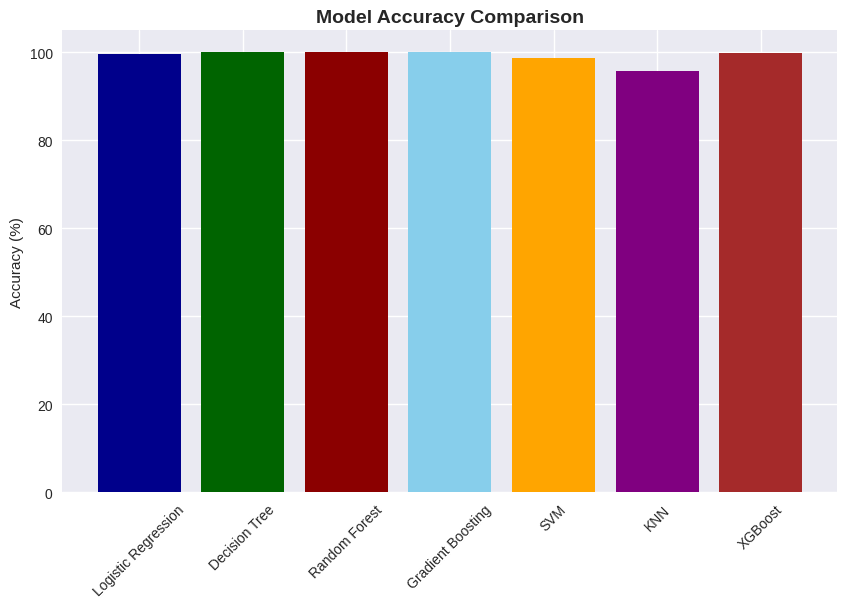

In [14]:
# Create target column: 1 if Close > PrevClose else 0
df['Target'] = np.where(df['Close'] > df['PrevClose'], 1, 0)

# Drop unnecessary columns
X = df.drop(['Date','Symbol','Target'], axis=1)
y = df['Target']

# Replace inf and -inf with NaN
X.replace([np.inf, -np.inf], np.nan, inplace=True)

# Fill missing values with column median
X.fillna(X.median(), inplace=True)

# Label Encoding (only needed if categorical columns exist, but keeping safe)
le = LabelEncoder()
if 'Symbol' in df.columns:
    df['Symbol'] = le.fit_transform(df['Symbol'])

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "Gradient Boosting": GradientBoostingClassifier(),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier(),
    "XGBoost": xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

# Train, predict, and calculate accuracy
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred) * 100
    results[name] = acc
    print(f"{name:<20} : {acc:.2f} %")

# Plot Accuracy Bar Graph
plt.figure(figsize=(10,6))
plt.bar(results.keys(), results.values(), color=['darkblue','darkgreen','darkred','skyblue','orange','purple','brown'])
plt.title("Model Accuracy Comparison", fontsize=14, weight="bold")
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=45)
plt.show()

## Thank you...pls upvote!!!!!
